# Lab 6.01 - Regression analysis

In [1]:
# Package imports
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Dataframe
import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic plot
import seaborn as sns                               # Advanced dataviz
from sklearn.linear_model import LinearRegression

## Exercise 1: Relation between heart weight and body weight in Cats

### Part 1

Perform a linear regression analysis on the variables body weight (`Bwt`, dependent variable) and heart weight (`Hwt`, independent variabele).


1. Import the dataset `Cats.csv`.


In [2]:
cats = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/Cats.csv')
# Show the first few records of the Data Frame
cats.head()

,ID,Sex,Hwt,Bwt
0,1,F,2.0,7.0
1,2,F,2.0,7.4
2,3,F,2.0,9.5
3,4,F,2.1,7.2
4,5,F,2.1,7.3


2. Draw a scatter plot of both variables.


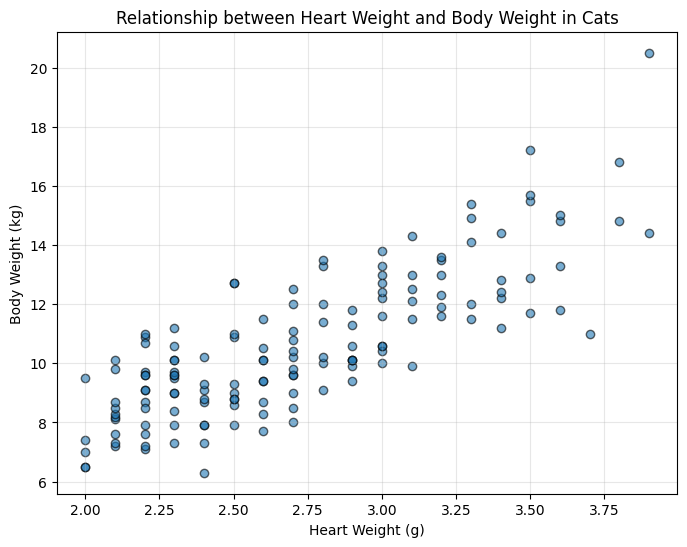

In [3]:
plt.figure(figsize=(8, 6))
plt.scatter(cats['Hwt'], cats['Bwt'], alpha=0.6, edgecolors='k')
plt.xlabel('Heart Weight (g)')
plt.ylabel('Body Weight (kg)')
plt.title('Relationship between Heart Weight and Body Weight in Cats')
plt.grid(True, alpha=0.3)
plt.show()

3. Calculate and draw the regression line.


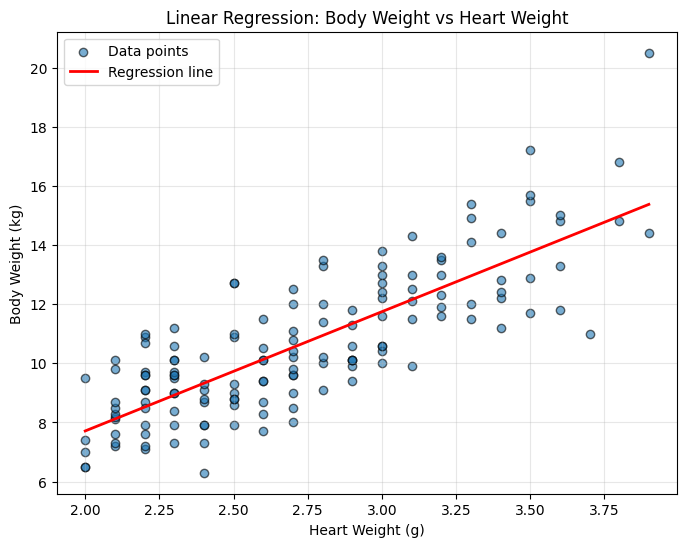

Regression line: ŷ = -0.3510783771969628 + 4.031757486783178 x


In [4]:
# Voorbereiding: X en y definiëren
X = cats[['Hwt']].values
y = cats['Bwt'].values

# Linear regression model
model = LinearRegression()
model.fit(X, y)

# Parameters
beta_0 = model.intercept_
beta_1 = model.coef_[0]

# Voorspellingen voor de regressielijn
X_line = np.array([[cats['Hwt'].min()], [cats['Hwt'].max()]])
y_line = model.predict(X_line)

# Visualisatie
plt.figure(figsize=(8, 6))
plt.scatter(cats['Hwt'], cats['Bwt'], alpha=0.6, edgecolors='k', label='Data points')
plt.plot(X_line, y_line, color='red', linewidth=2, label='Regression line')
plt.xlabel('Heart Weight (g)')
plt.ylabel('Body Weight (kg)')
plt.title('Linear Regression: Body Weight vs Heart Weight')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Regression line: ŷ = {beta_0} + {beta_1} x")

4. Calculate the correlation coefficient and the coefficient of determination.

In [5]:
# Pearson correlation coefficient
correlation = np.corrcoef(cats['Hwt'], cats['Bwt'])[0, 1]

# Coefficient of determination (R²)
r_squared = correlation ** 2

print(f"Correlation coefficient (R): {correlation}")
print(f"Coefficient of determination (R²): {r_squared}")

Correlation coefficient (R): 0.804134787315513
Coefficient of determination (R²): 0.6466327561709654


5. Interpret the results from the previous steps.

In [ ]:
De lineaire regressieanalyse toont aan dat er een sterke positieve correlatie bestaat tussen hartgewicht en lichaamsgewicht van katten. De regressielijn kan worden gebruikt voor voorspellingen.

### Part 2

1. Perform a linear regression analysis on the variables body weight (`Bwt`) and heart weight (`Hwt`), but this time **subdivided by gender** (`Sex`). Use the same dataset (`Cats.csv`).


In [7]:
cats = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/Cats.csv')
# Show the first few records of the Data Frame
cats.head()

,ID,Sex,Hwt,Bwt
0,1,F,2.0,7.0
1,2,F,2.0,7.4
2,3,F,2.0,9.5
3,4,F,2.1,7.2
4,5,F,2.1,7.3


2. Draw a scatter plot of both variables for each gender.


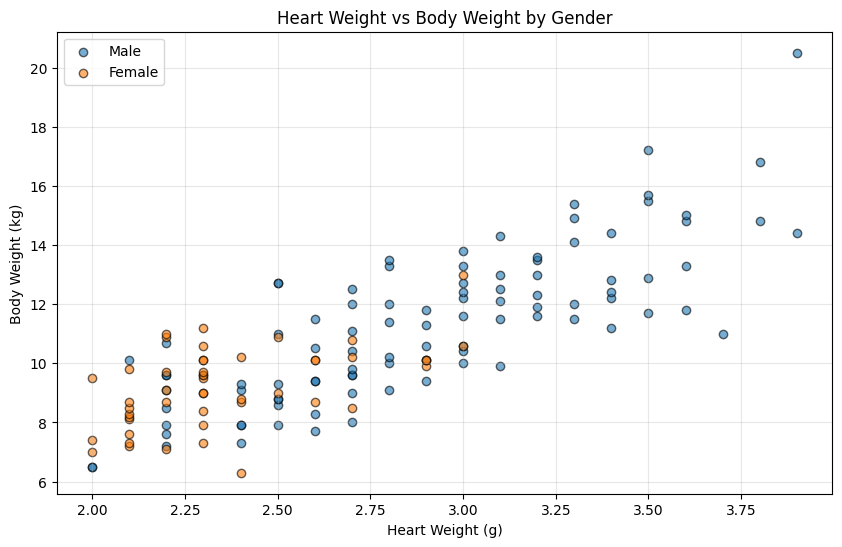

In [8]:
plt.figure(figsize=(10, 6))

# Plot voor males
males = cats[cats['Sex'] == 'M']
females = cats[cats['Sex'] == 'F']

plt.scatter(males['Hwt'], males['Bwt'], alpha=0.6, label='Male', edgecolors='k')
plt.scatter(females['Hwt'], females['Bwt'], alpha=0.6, label='Female', edgecolors='k')

plt.xlabel('Heart Weight (g)')
plt.ylabel('Body Weight (kg)')
plt.title('Heart Weight vs Body Weight by Gender')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

3. Calculate and draw the regression line.



Male:
Regression line: ŷ = -1.1768252533094827 + 4.309818875119161 x
Correlation (R): 0.7930443171812304
R²: 0.628919289013444

Female:
Regression line: ŷ = 2.981312384473198 + 2.6364140480591494 x
Correlation (R): 0.5320496665060397
R²: 0.28307684762918806


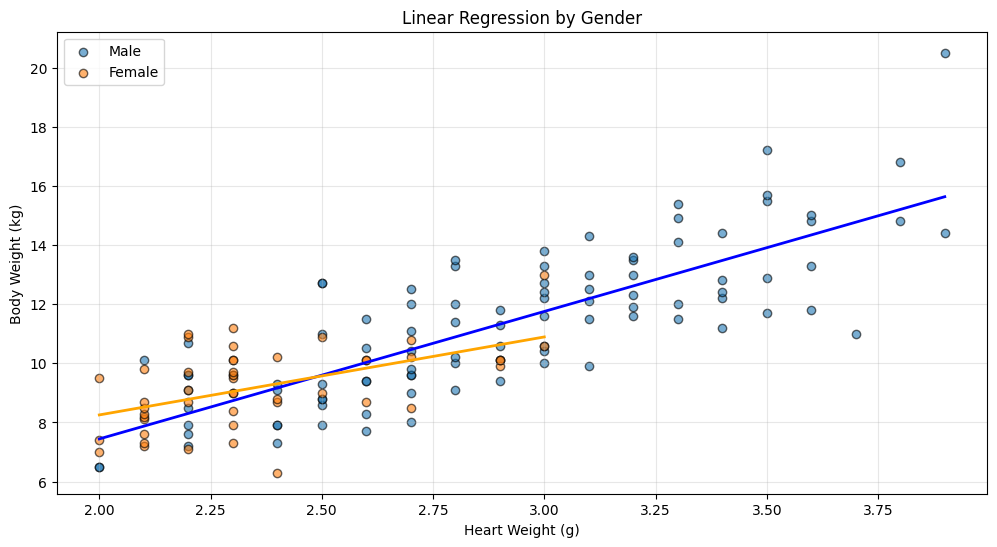

In [9]:
# Function to fit regression for a group
def fit_regression(data, group_name):
    X = data[['Hwt']].values
    y = data['Bwt'].values

    model = LinearRegression()
    model.fit(X, y)

    beta_0 = model.intercept_
    beta_1 = model.coef_[0]

    correlation = np.corrcoef(data['Hwt'], data['Bwt'])[0, 1]
    r_squared = correlation ** 2

    print(f"\n{group_name}:")
    print(f"Regression line: ŷ = {beta_0} + {beta_1} x")
    print(f"Correlation (R): {correlation}")
    print(f"R²: {r_squared}")

    return model, X, y, beta_0, beta_1, correlation, r_squared

# Fit regression for males and females
male_model, male_X, male_y, male_b0, male_b1, male_r, male_r2 = fit_regression(males, "Male")
female_model, female_X, female_y, female_b0, female_b1, female_r, female_r2 = fit_regression(females, "Female")

# Visualisatie met regressielijnen
plt.figure(figsize=(12, 6))

# Males
plt.scatter(males['Hwt'], males['Bwt'], alpha=0.6, label='Male', edgecolors='k')
X_line_m = np.array([[males['Hwt'].min()], [males['Hwt'].max()]])
y_line_m = male_model.predict(X_line_m)
plt.plot(X_line_m, y_line_m, color='blue', linewidth=2)

# Females
plt.scatter(females['Hwt'], females['Bwt'], alpha=0.6, label='Female', edgecolors='k')
X_line_f = np.array([[females['Hwt'].min()], [females['Hwt'].max()]])
y_line_f = female_model.predict(X_line_f)
plt.plot(X_line_f, y_line_f, color='orange', linewidth=2)

plt.xlabel('Heart Weight (g)')
plt.ylabel('Body Weight (kg)')
plt.title('Linear Regression by Gender')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

4. Calculate the correlation coefficient and the coefficient of determination.


In [ ]:
De bovenstaande functie berekent al deze waarden.

5. Interpret the results from the previous steps.

In [ ]:
De regressieanalyse per geslacht toont verschillende relaties: mannelijke katten vertonen een sterkere lineaire relatie dan vrouwelijke katten.

### Answers

| Selection |  $\beta_0$ | $\beta_1$ |       $R$ |     $R^2$ |
| :-------- | ---------: | --------: | --------: | --------: |
| All       | -0.3510784 | 4.0317575 | 0.8041348 | 0.6466328 |
| Male      | -1.1768253 | 4.3098189 | 0.7930443 | 0.6289193 |
| Female    |  2.9813124 |  2.636414 | 0.5320497 | 0.2830768 |
